# Анализ количества базовых станций
**Вариант 10. Решение на R.**

**Задание:**
1. Вырезать таблицу отдельно по округам
2. Вырезать таблицы отдельно по високосным годам, нечетным годам, четным годам
3. Найти максимумы - по округам, субъектам федерации, за все время, построить графики зависимости
4. Построить гистограммы на каждый год по всем годам, - то же самое но отдельно по округам, подогнать к гистограммам расперделение - нормальное или другое
---

In [2]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(stringr)
})

df <- read.csv("data.csv", skip = 4, sep = ";", fileEncoding = "windows-1251", 
               check.names = FALSE, stringsAsFactors = FALSE)

if (ncol(df) < 5) {
  df <- read.csv("data.csv", skip = 4, sep = ",", fileEncoding = "windows-1251", 
                 check.names = FALSE, stringsAsFactors = FALSE)
}

colnames(df)[1] <- "Регион"
years <- grep("^[0-9]{4}$", colnames(df), value = TRUE)
df <- df[, c("Регион", years)]
df <- df %>% filter(Регион != "", !str_detect(Регион, regex("квартал", ignore_case=TRUE)))

clean_numeric <- function(x) {
  x <- gsub("[[:space:]]|\U00A0", "", x)
  x <- gsub(",", ".", x)
  x <- ifelse(x %in% c("-", "...", "", "\u2026"), NA, x)
  suppressWarnings(as.numeric(x))
}
df[years] <- lapply(df[years], clean_numeric)
head(df)

Warning message:
"пакет 'dplyr' был собран под R версии 4.5.2"
Warning message:
"пакет 'tidyr' был собран под R версии 4.5.2"
Warning message:
"пакет 'ggplot2' был собран под R версии 4.5.2"
Warning message:
"пакет 'stringr' был собран под R версии 4.5.2"


,Регион,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,АЛТАЙСКИЙ КРАЙ,1717,2158,2388,2739,3404,4676,4965,5326,6212,7171,7879,9314,9933,10436,12257
2,АМУРСКАЯ ОБЛАСТЬ,452,1156,1534,1816,2389,2580,2711,2832,2975,3629,4095,4427,4592,4770,5394
3,АРХАНГЕЛЬСКАЯ ОБЛАСТЬ,1337,1831,1941,2163,2173,2605,3081,3345,3729,4102,4364,4717,4866,5199,5820
4,АСТРАХАНСКАЯ ОБЛАСТЬ,977,1185,1346,1473,2068,2139,2074,2172,2219,2848,3110,3233,4163,3728,4027
5,БЕЛГОРОДСКАЯ ОБЛАСТЬ,1165,1354,1448,1705,2275,2768,3288,3840,4454,4988,5497,6113,6235,7398,8327
6,БРЯНСКАЯ ОБЛАСТЬ,1161,1229,1394,1501,2023,2191,2583,2813,3399,4051,4464,4569,4589,5239,6077


## Пункт 1: Вырезать таблицу отдельно по округам

In [3]:
districts_df <- df %>% filter(str_detect(Регион, regex("федеральный округ", ignore_case = TRUE)))
write.csv(districts_df, "Таблица_Округа.csv", row.names = FALSE, fileEncoding = "UTF-8")
print("Таблица по округам:")
head(districts_df)

[1] "Таблица по округам:"


,Регион,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Дальневосточный федеральный округ,4748,7379,9693,11348,15069,18172,19185,20487,29916,34690,38206,41295,43741,46132,49028
2,Крымский федеральный округ,NA,NA,NA,NA,NA,1437,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,Приволжский федеральный округ,26834,32070,37063,42111,52719,60561,68574,73757,85663,99117,110305,120003,125296,134826,152816
4,Северо-Западный федеральный округ,18650,23691,26540,29297,30479,35665,44329,49989,57632,64161,69904,79871,87278,93682,93195
5,Северо-Кавказский федеральный округ,5839,8302,9263,12241,16205,19547,21001,22407,24529,26840,28787,30565,32884,35046,41268
6,Сибирский федеральный округ,16954,21130,24839,27851,34535,41315,45835,50438,52870,60122,66952,75224,80578,85518,93567


## Пункт 2: Вырезать таблицы отдельно по високосным, нечетным и четным годам

In [4]:
years_num <- as.numeric(years)

leap_years <- years[years_num %% 4 == 0 & (years_num %% 100 != 0 | years_num %% 400 == 0)]
odd_years <- years[years_num %% 2 != 0]
even_years <- years[years_num %% 2 == 0 & !(years %in% leap_years)]

df_leap <- df %>% select(Регион, all_of(leap_years))
df_odd <- df %>% select(Регион, all_of(odd_years))
df_even <- df %>% select(Регион, all_of(even_years))

write.csv(df_leap, "Таблица_Високосные.csv", row.names = FALSE, fileEncoding = "UTF-8")
write.csv(df_odd, "Таблица_Нечетные.csv", row.names = FALSE, fileEncoding = "UTF-8")
write.csv(df_even, "Таблица_Четные.csv", row.names = FALSE, fileEncoding = "UTF-8")

print("Високосные годы (шапка таблицы):")
head(df_leap)
print("Нечетные годы (шапка таблицы):")
head(df_odd)
print("Четные годы (шапка таблицы):")
head(df_even)

[1] "Високосные годы (шапка таблицы):"


,Регион,2012,2016,2020,2024
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,АЛТАЙСКИЙ КРАЙ,2388,4965,7879,12257
2,АМУРСКАЯ ОБЛАСТЬ,1534,2711,4095,5394
3,АРХАНГЕЛЬСКАЯ ОБЛАСТЬ,1941,3081,4364,5820
4,АСТРАХАНСКАЯ ОБЛАСТЬ,1346,2074,3110,4027
5,БЕЛГОРОДСКАЯ ОБЛАСТЬ,1448,3288,5497,8327
6,БРЯНСКАЯ ОБЛАСТЬ,1394,2583,4464,6077


[1] "Нечетные годы (шапка таблицы):"


,Регион,2011,2013,2015,2017,2019,2021,2023
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,АЛТАЙСКИЙ КРАЙ,2158,2739,4676,5326,7171,9314,10436
2,АМУРСКАЯ ОБЛАСТЬ,1156,1816,2580,2832,3629,4427,4770
3,АРХАНГЕЛЬСКАЯ ОБЛАСТЬ,1831,2163,2605,3345,4102,4717,5199
4,АСТРАХАНСКАЯ ОБЛАСТЬ,1185,1473,2139,2172,2848,3233,3728
5,БЕЛГОРОДСКАЯ ОБЛАСТЬ,1354,1705,2768,3840,4988,6113,7398
6,БРЯНСКАЯ ОБЛАСТЬ,1229,1501,2191,2813,4051,4569,5239


[1] "Четные годы (шапка таблицы):"


,Регион,2010,2014,2018,2022
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,АЛТАЙСКИЙ КРАЙ,1717,3404,6212,9933
2,АМУРСКАЯ ОБЛАСТЬ,452,2389,2975,4592
3,АРХАНГЕЛЬСКАЯ ОБЛАСТЬ,1337,2173,3729,4866
4,АСТРАХАНСКАЯ ОБЛАСТЬ,977,2068,2219,4163
5,БЕЛГОРОДСКАЯ ОБЛАСТЬ,1165,2275,4454,6235
6,БРЯНСКАЯ ОБЛАСТЬ,1161,2023,3399,4589


## Пункт 3: Найти максимумы - по округам, субъектам федерации, за все время, построить графики зависимости

[1] "=== Максимумы по Округам за все время ==="
                                Округ Максимум
1   Дальневосточный федеральный округ    49028
2          Крымский федеральный округ     1437
3       Приволжский федеральный округ   152816
4   Северо-Западный федеральный округ    93682
5 Северо-Кавказский федеральный округ    41268
6         Сибирский федеральный округ    93567
7         Уральский федеральный округ    71999
8       Центральный федеральный округ   255711
9             Южный федеральный округ    94804
[1] "\n=== Максимумы по Субъектам за все время (Топ-15) ==="
                   Субъект Максимум
1                г. МОСКВА   150678
2       г. САНКТ-ПЕТЕРБУРГ    56332
3       КРАСНОДАРСКИЙ КРАЙ    36568
4     СВЕРДЛОВСКАЯ ОБЛАСТЬ    27858
5     РЕСПУБЛИКА ТАТАРСТАН    26356
6       РОСТОВСКАЯ ОБЛАСТЬ    23446
7    НОВОСИБИРСКАЯ ОБЛАСТЬ    18669
8    НИЖЕГОРОДСКАЯ ОБЛАСТЬ    17936
9        САМАРСКАЯ ОБЛАСТЬ    16948
10         РЕСПУБЛИКА КРЫМ    15873
11 РЕСПУБЛИКА БАШКОРТОСТА

Warning message:
"Removed 14 rows containing missing values or values outside the scale range (`geom_line()`)."
Warning message:
"Removed 14 rows containing missing values or values outside the scale range (`geom_point()`)."
Warning message:
"Removed 5 rows containing missing values or values outside the scale range (`geom_line()`)."
Warning message:
"Removed 5 rows containing missing values or values outside the scale range (`geom_point()`)."


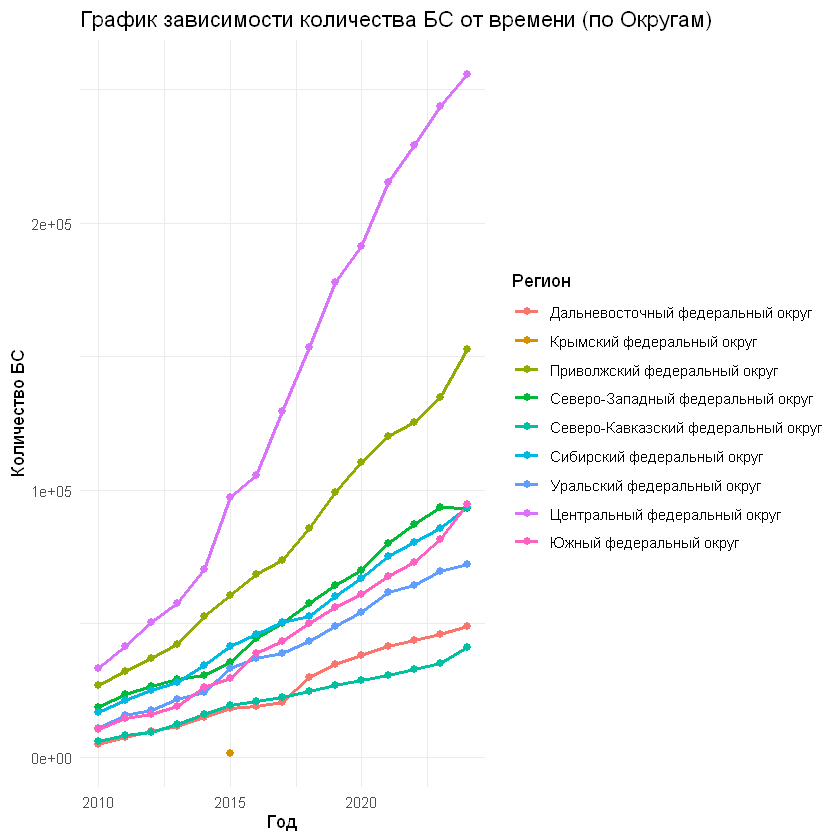

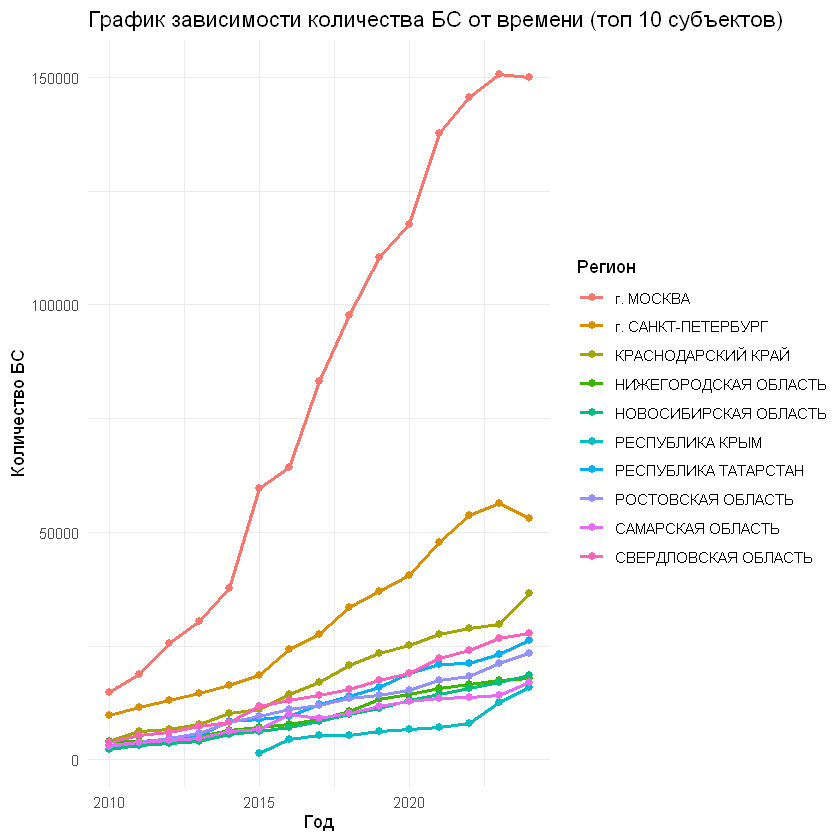

In [5]:
df_regions <- df %>% filter(!str_detect(Регион, regex("Российская Федерация", ignore_case = TRUE)))
subjects_df <- df_regions %>% filter(!str_detect(Регион, regex("федеральный округ", ignore_case = TRUE)))

safe_max <- function(row) { if(all(is.na(row))) NA else max(row, na.rm = TRUE) }

# 1. ВЫПИСЫВАЕМ МАКСИМУМЫ ОТДЕЛЬНО
dist_max_df <- data.frame(Округ = districts_df$Регион, Максимум = apply(districts_df[years], 1, safe_max))
subj_max_df <- data.frame(Субъект = subjects_df$Регион, Максимум = apply(subjects_df[years], 1, safe_max))

print("=== Максимумы по Округам за все время ===")
print(dist_max_df)
print("\n=== Максимумы по Субъектам за все время (Топ-15) ===")
print(head(subj_max_df %>% arrange(desc(Максимум)), 15))

# 2. ПОСТРОЕНИЕ ГРАФИКОВ ЗАВИСИМОСТИ (График зависимости кол-ва станций от времени)
# Преобразуем данные в длинный формат для построения линейных графиков зависимости от года
dist_long <- districts_df %>% 
  pivot_longer(cols = all_of(years), names_to = "Год", values_to = "БС") %>% 
  mutate(Год = as.numeric(Год))

p1 <- ggplot(dist_long, aes(x = Год, y = БС, color = Регион)) +
  geom_line(linewidth = 1) + 
  geom_point(size = 2) +
  theme_minimal() +
  labs(title = "График зависимости количества БС от времени (по Округам)", 
       x = "Год", y = "Количество БС")
print(p1)

# Строим такой же график зависимости для Топ-10 Субъектов
top_subj_names <- head(subj_max_df %>% arrange(desc(Максимум)), 10)$Субъект
subj_long <- subjects_df %>% filter(Регион %in% top_subj_names) %>% 
  pivot_longer(cols = all_of(years), names_to = "Год", values_to = "БС") %>% 
  mutate(Год = as.numeric(Год))

p2 <- ggplot(subj_long, aes(x = Год, y = БС, color = Регион)) +
  geom_line(linewidth = 1) + 
  geom_point(size = 2) +
  theme_minimal() +
  labs(title = "График зависимости количества БС от времени (топ 10 субъектов)", 
       x = "Год", y = "Количество БС")
print(p2)


## Пункт 4.1: Построить гистограммы на КАЖДЫЙ год по ВСЕМ годам (по субъектам) и подогнать нормальное распределение

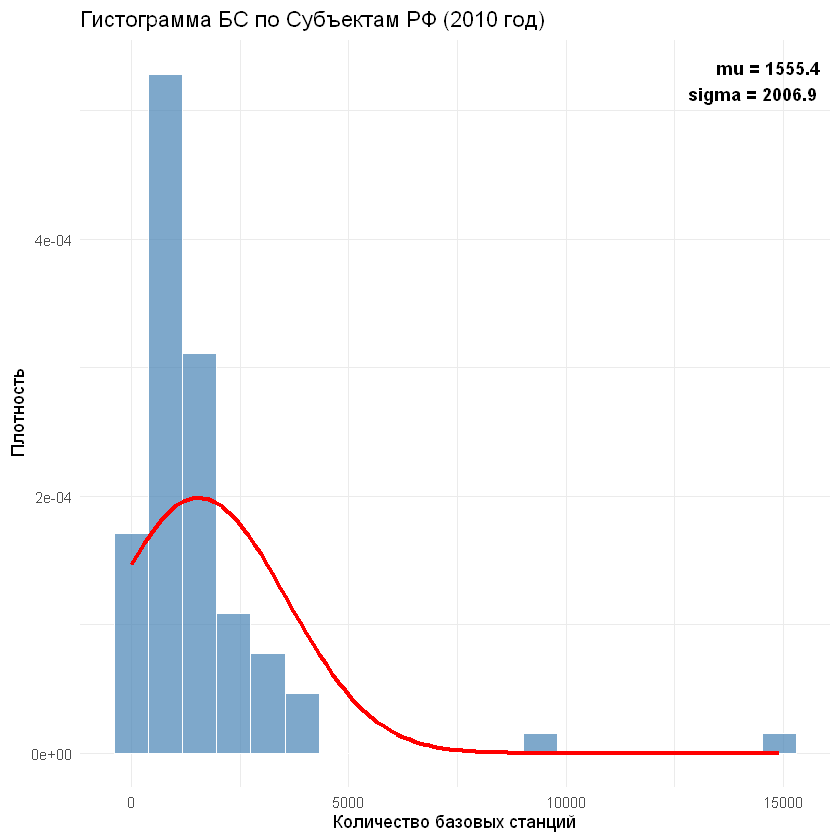

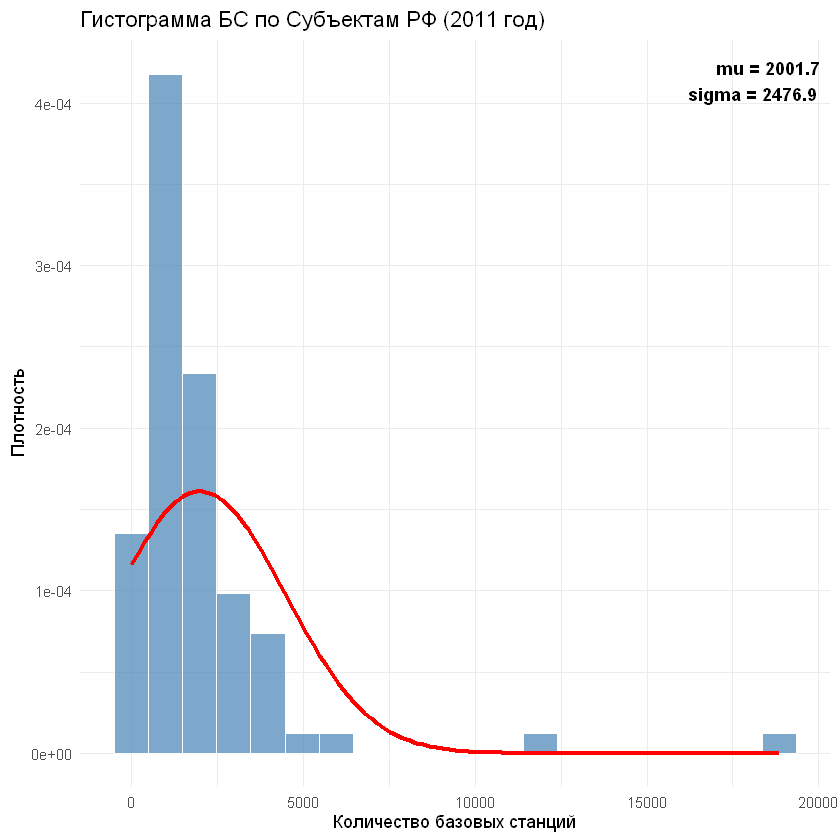

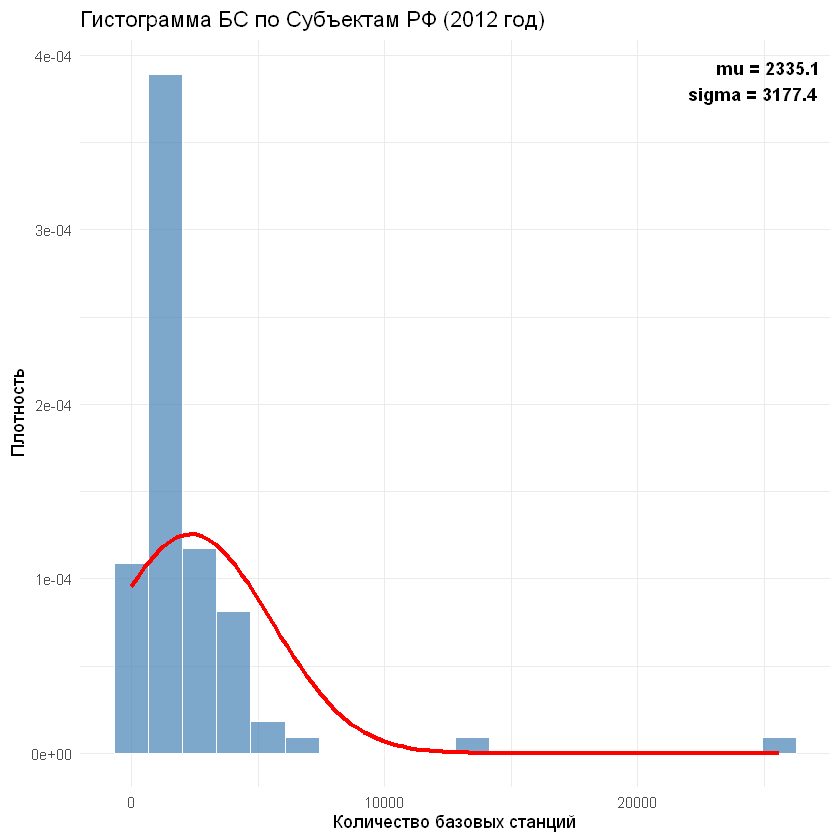

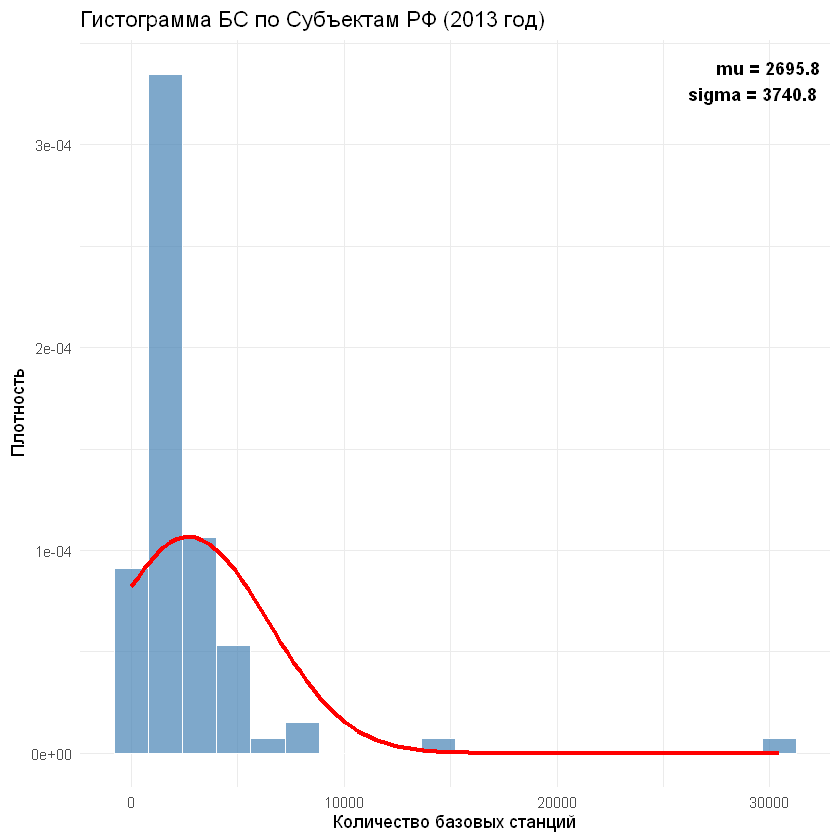

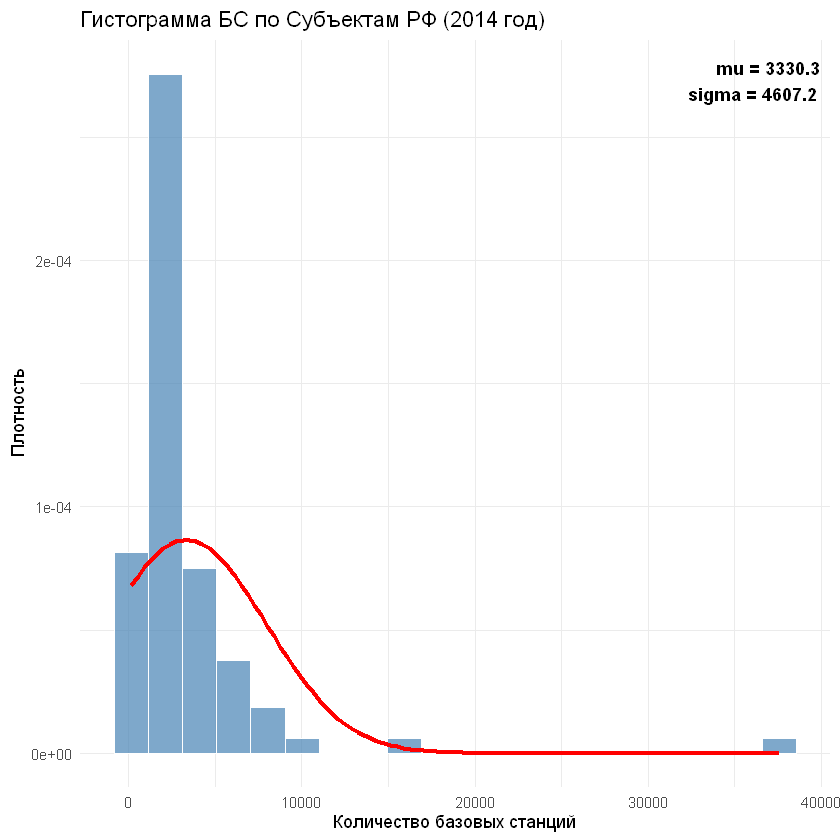

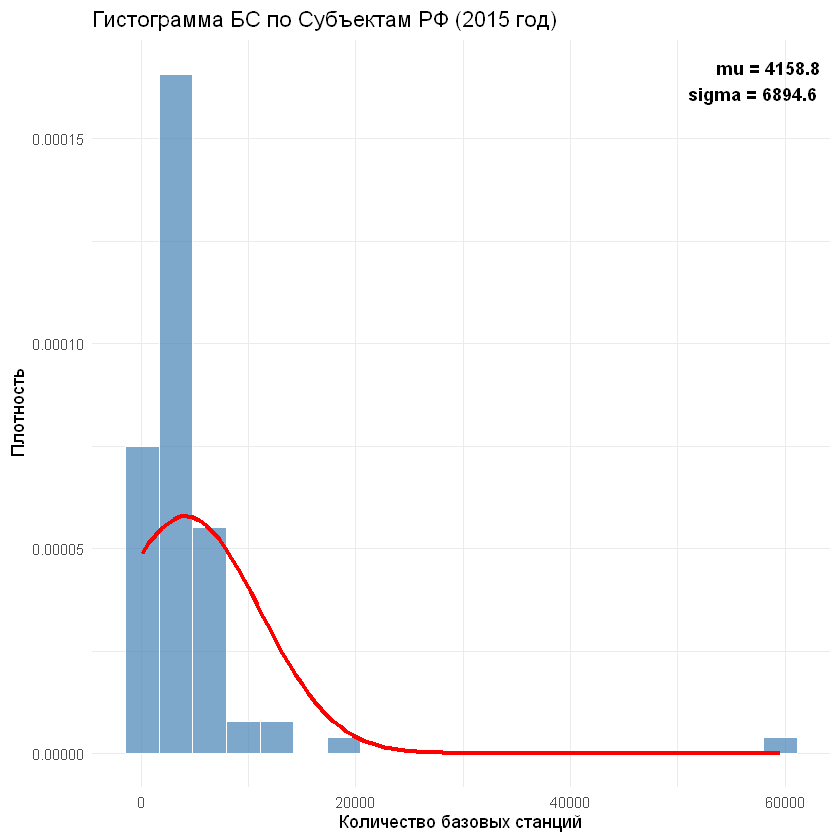

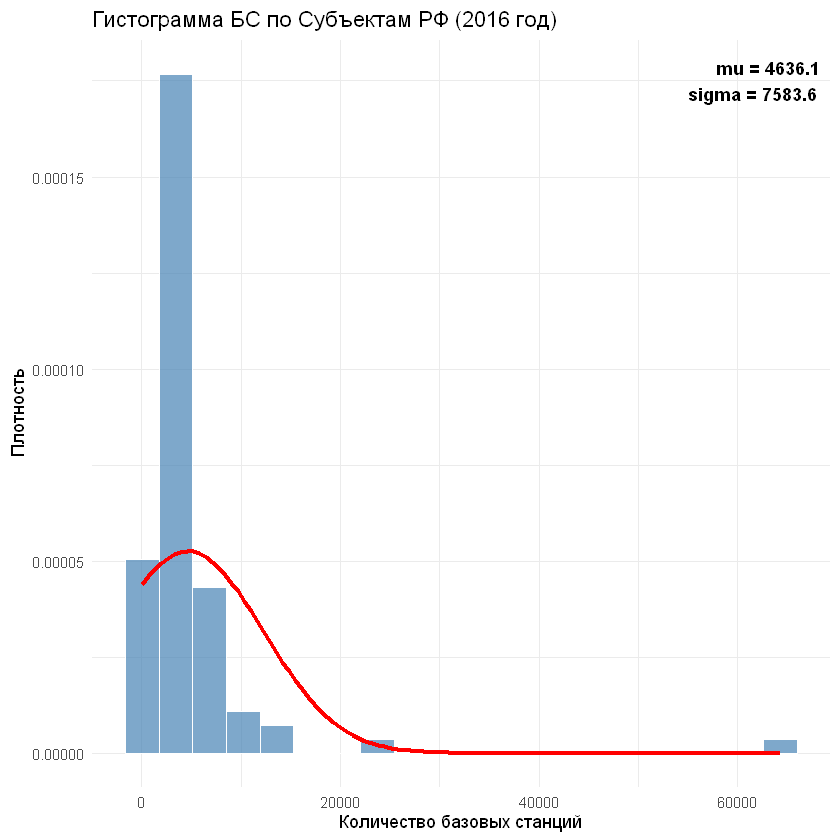

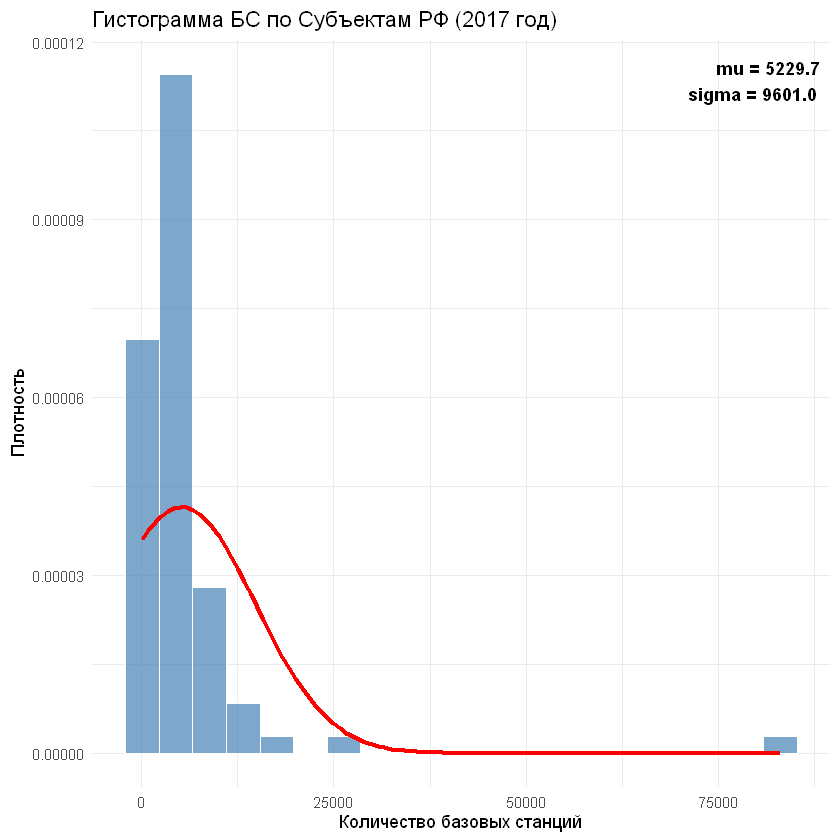

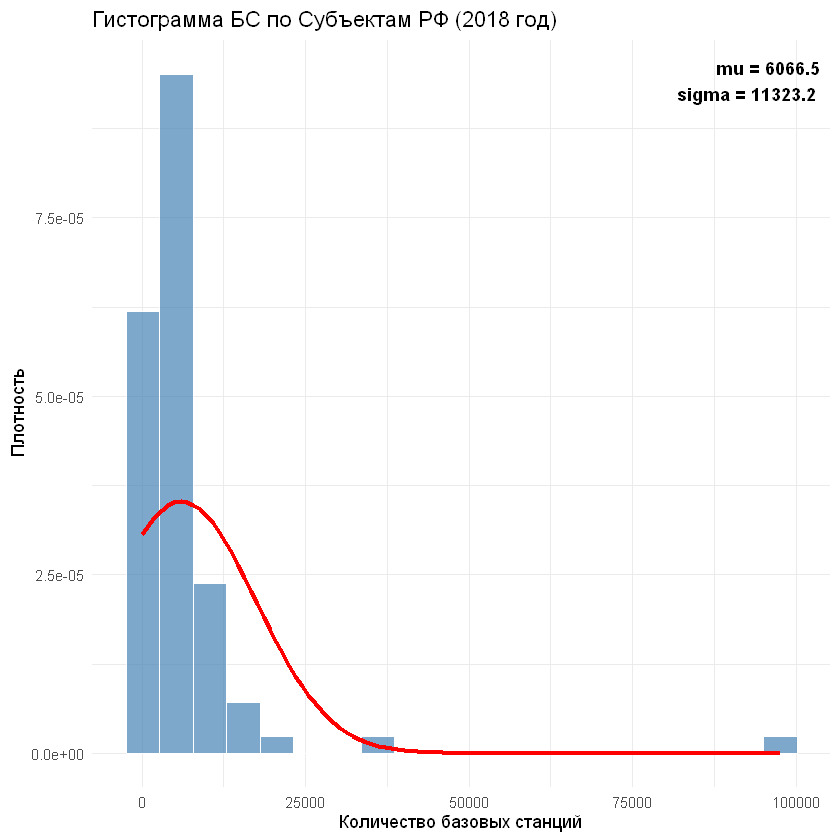

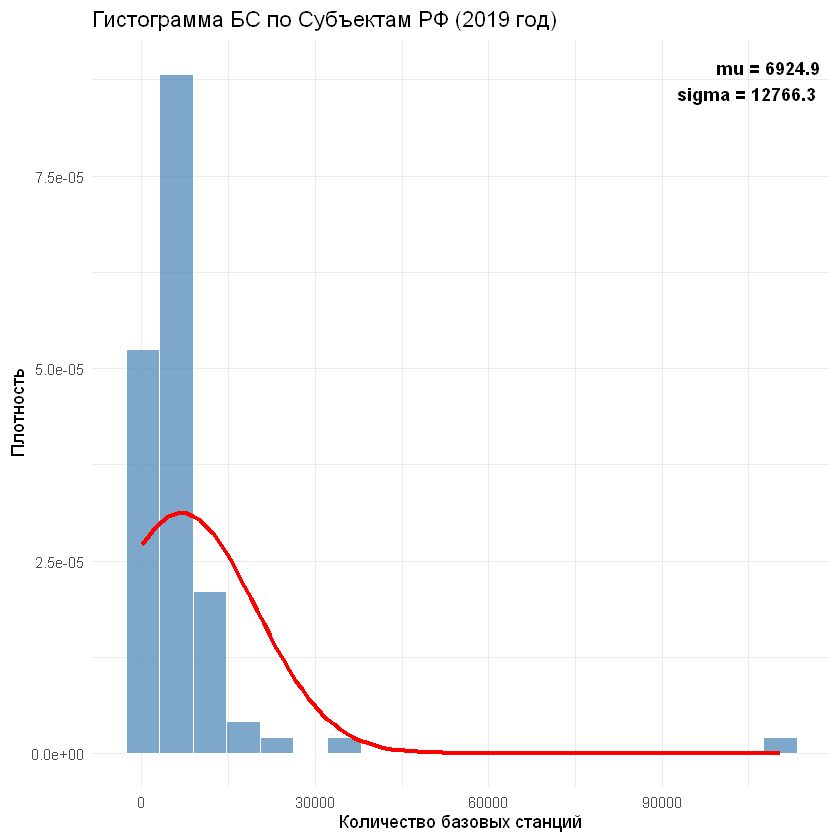

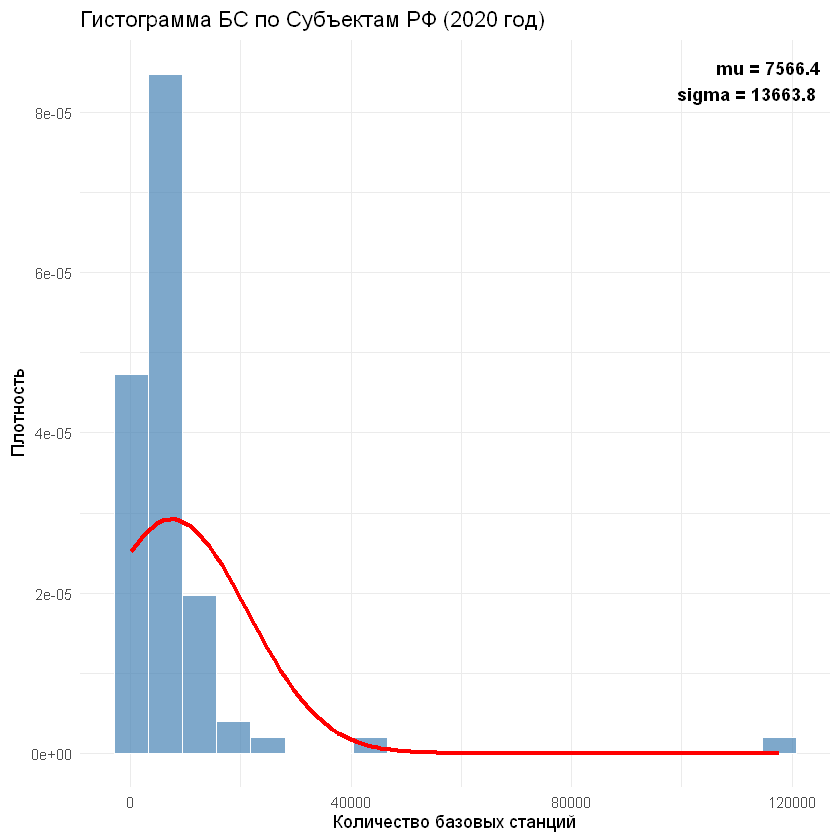

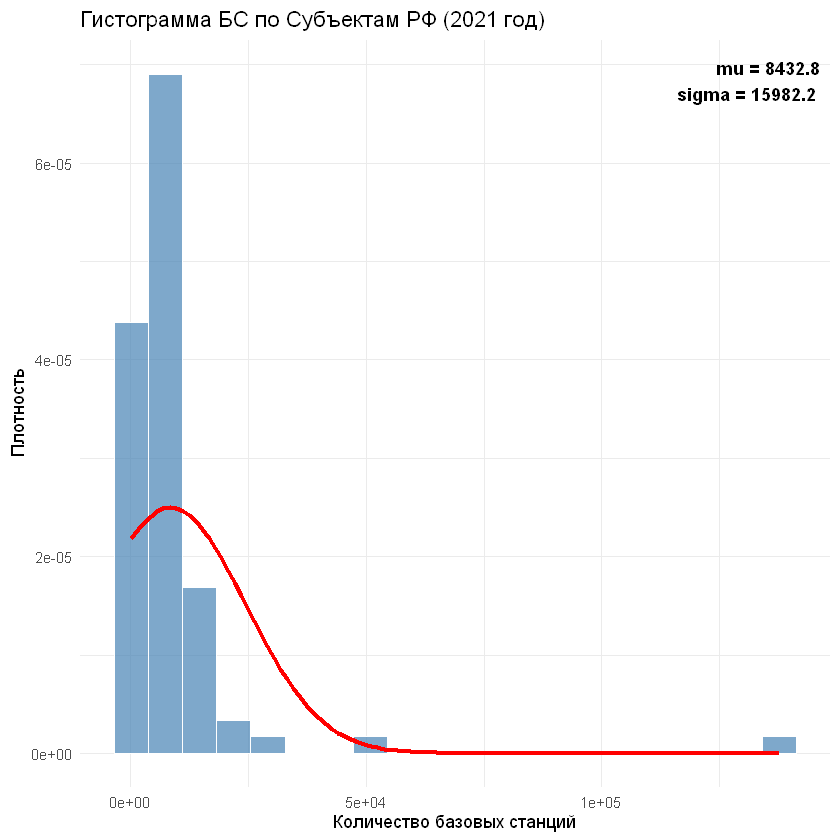

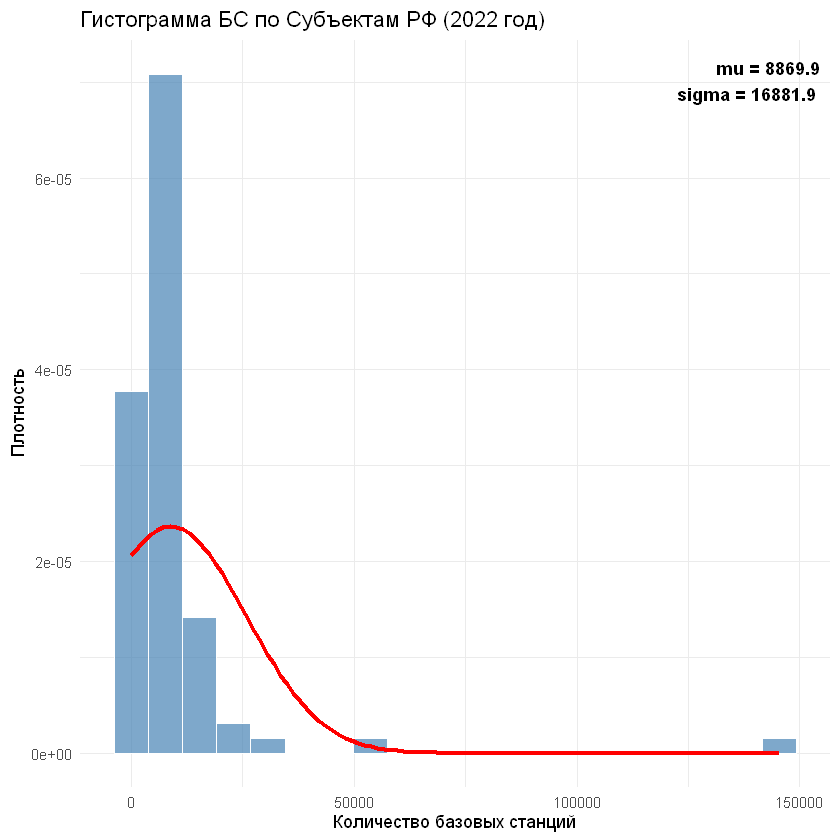

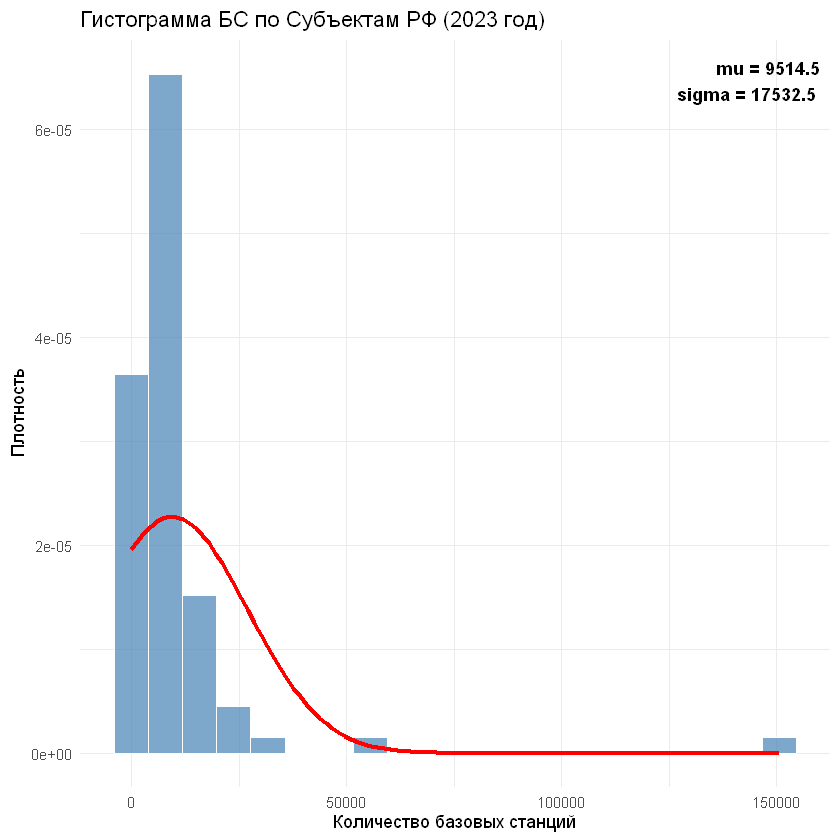

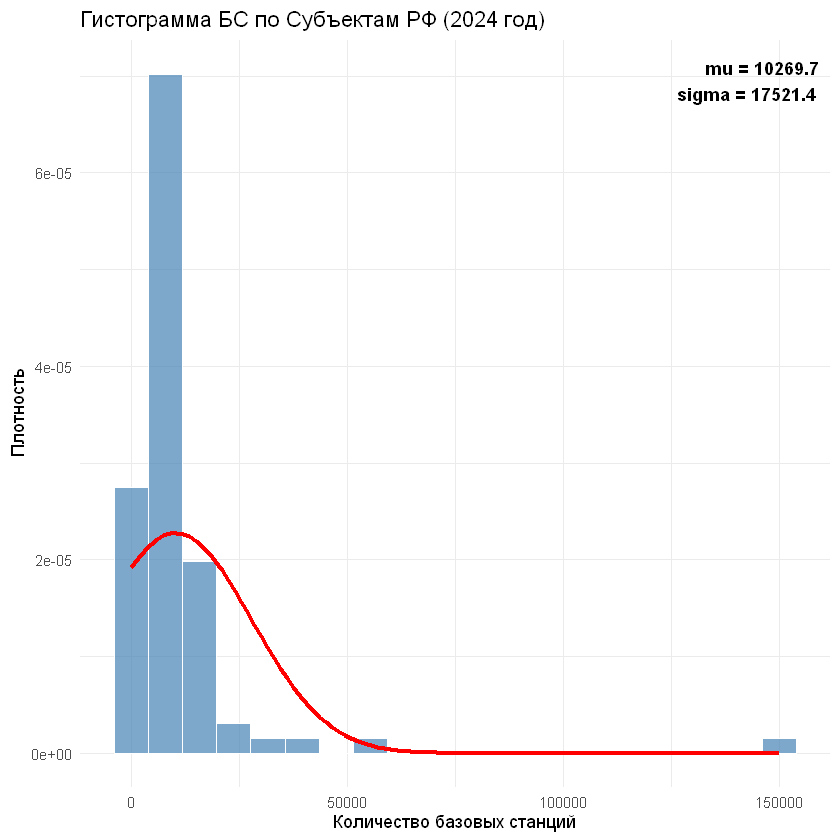

In [14]:
for (year in years) {
  data_year <- subjects_df[[year]]
  data_year <- data_year[!is.na(data_year)]
  
  if (length(data_year) > 1) {
    mu <- mean(data_year)
    sigma <- sd(data_year)
    
    p <- ggplot(data.frame(x = data_year), aes(x = x)) +
      geom_histogram(aes(y = after_stat(density)), bins = 20, fill = "steelblue", color="white", alpha = 0.7) +
      stat_function(fun = dnorm, args = list(mean = mu, sd = sigma), color = "red", linewidth = 1.2) +
      theme_minimal() +
      labs(title = paste("Гистограмма БС по Субъектам РФ (", year, " год)", sep=""),
           x = "Количество базовых станций", y = "Плотность") +
            annotate("text", x = Inf, y = Inf, label = sprintf("mu = %.1f\nsigma = %.1f", mu, sigma), 
               hjust = 1.1, vjust = 1.5, fontface="bold")
    print(p)
  }
}

## Пункт 4.2: То же самое (Гистограммы на каждый год), но отдельно по ОКРУГАМ

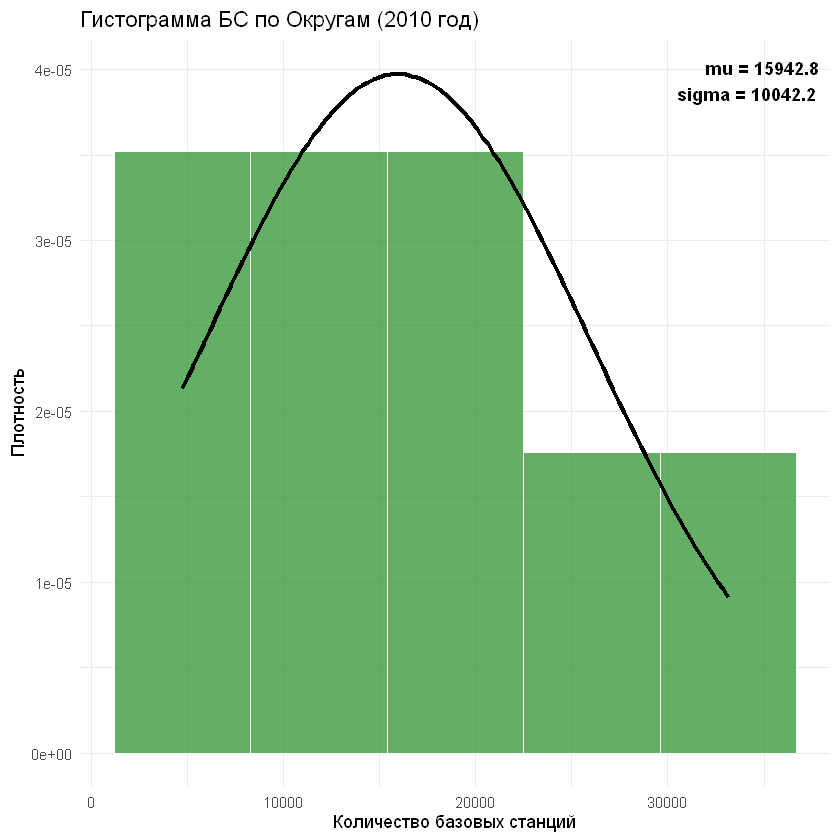

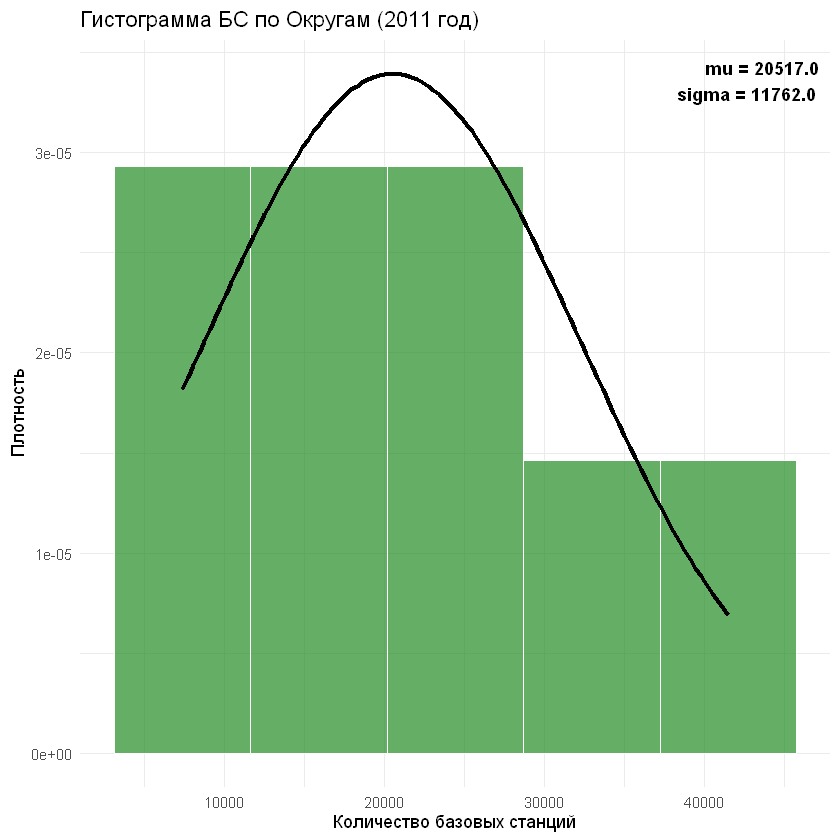

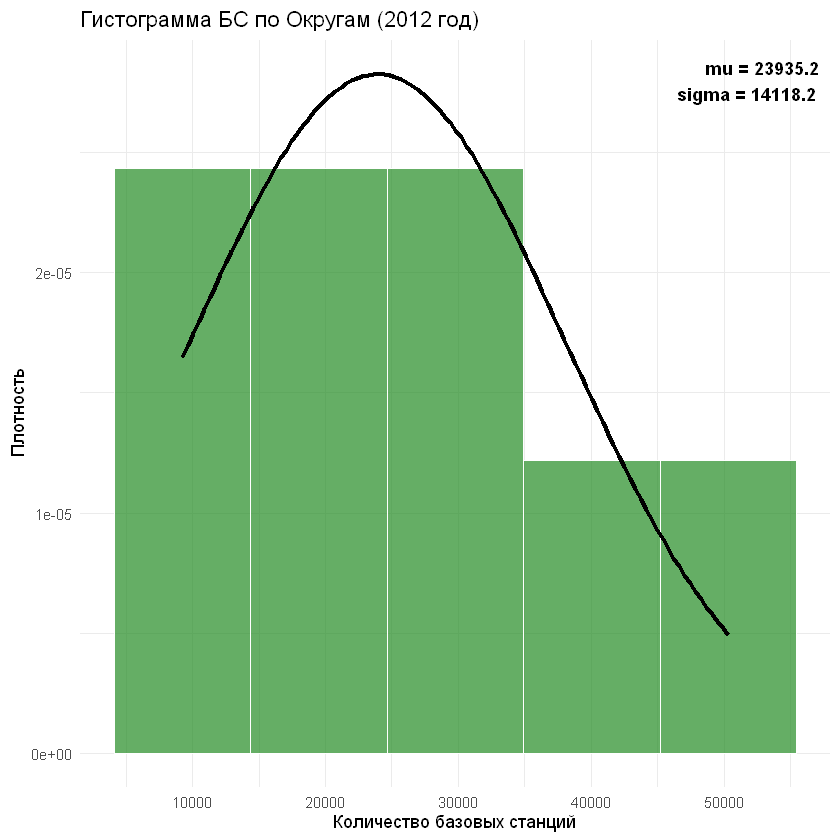

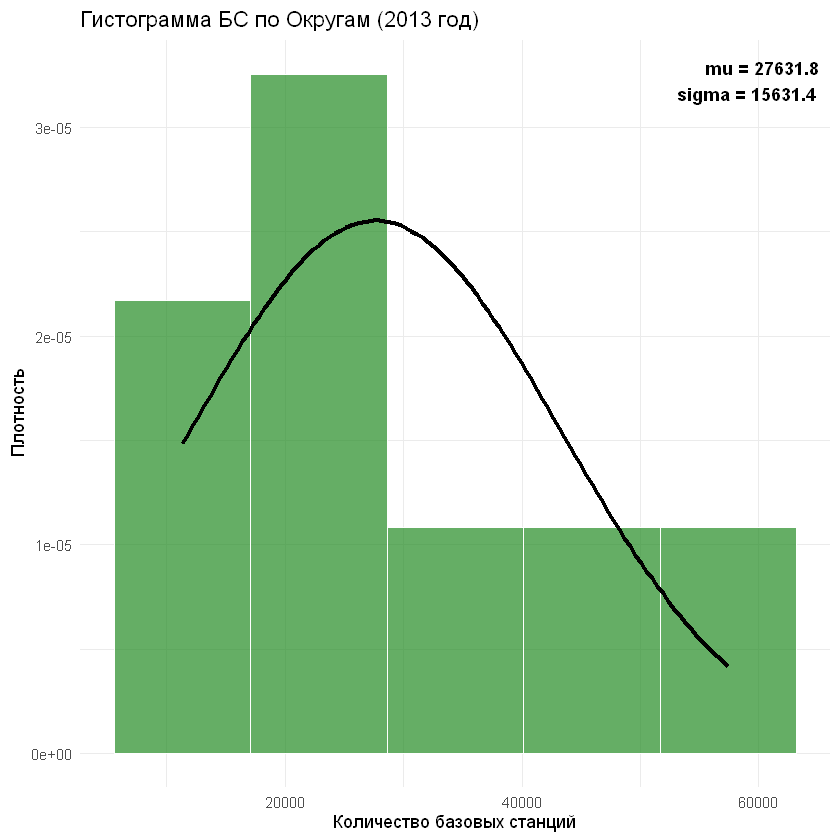

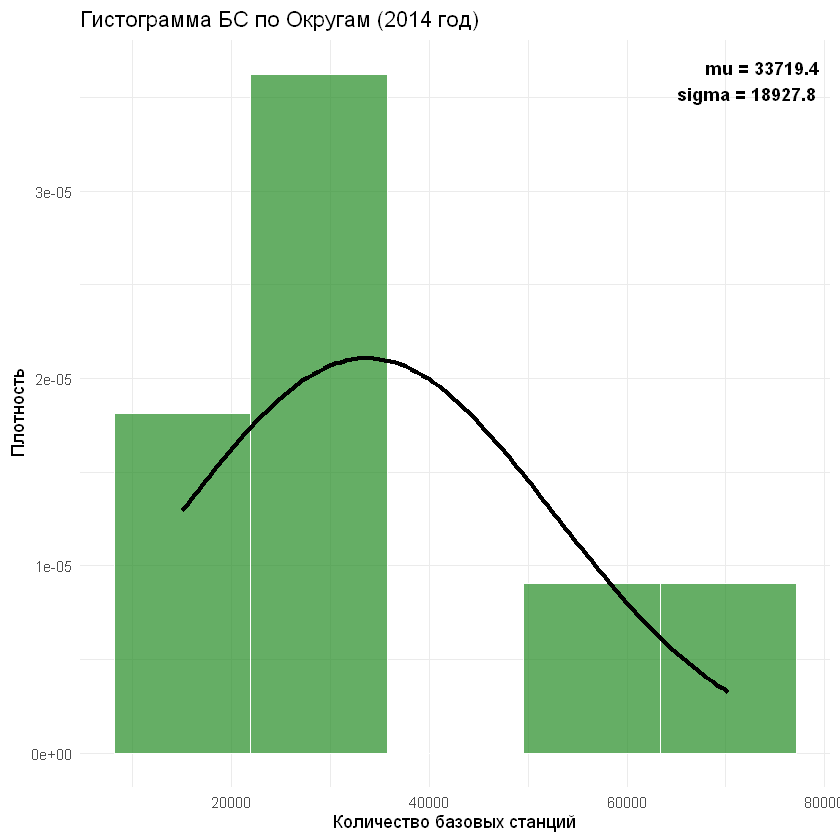

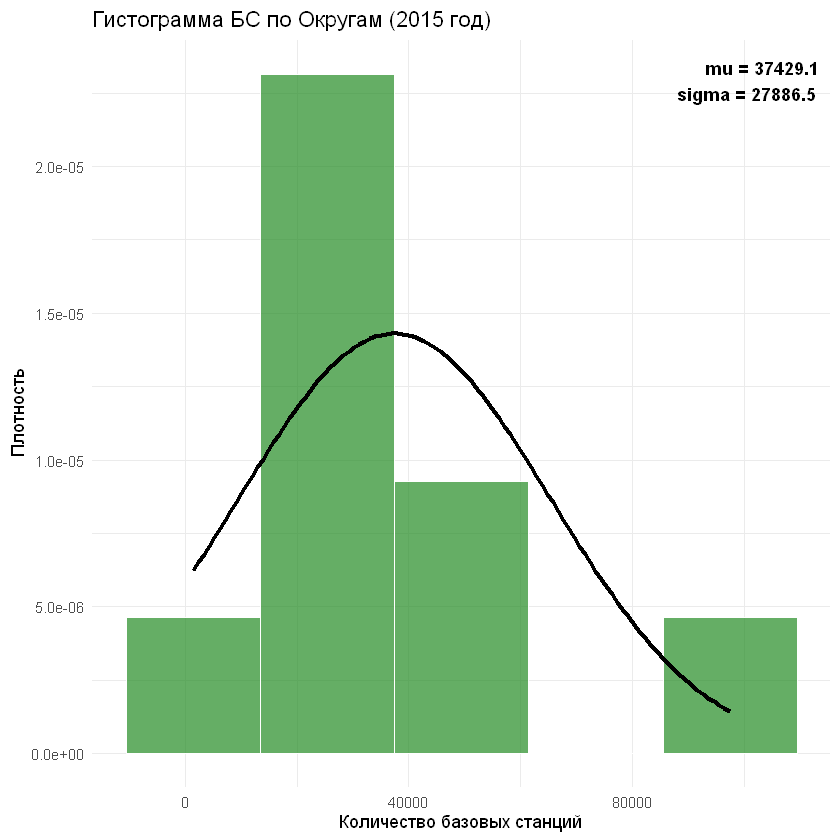

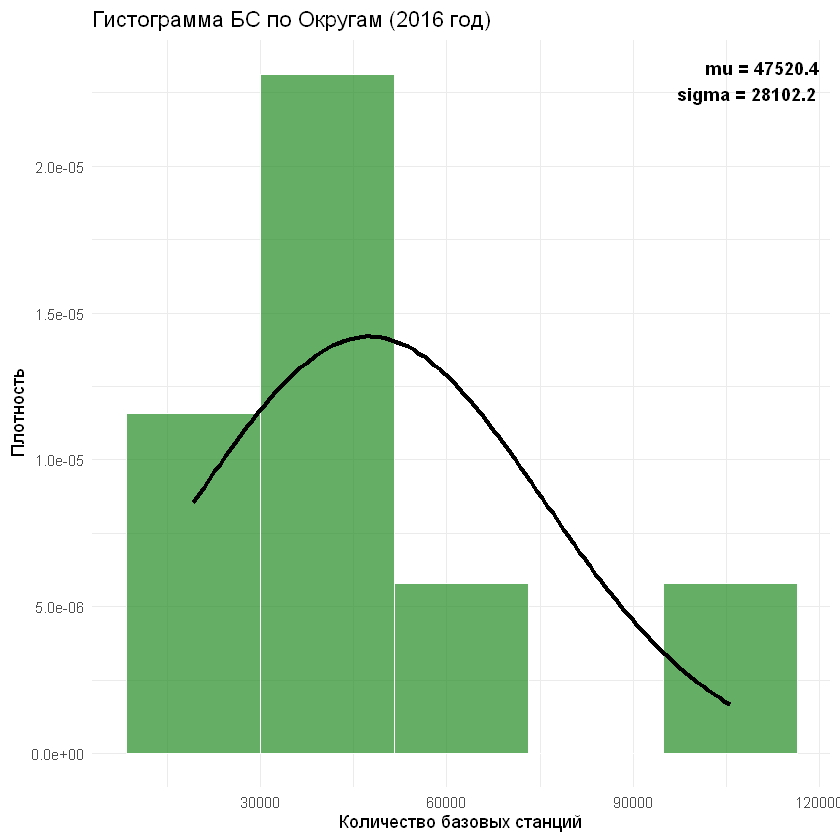

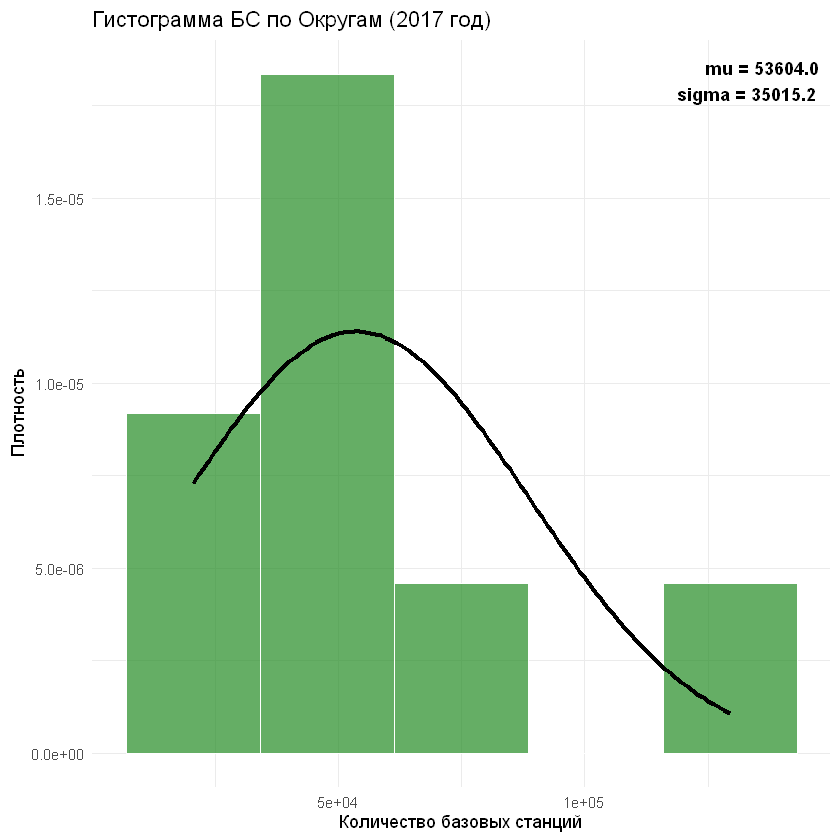

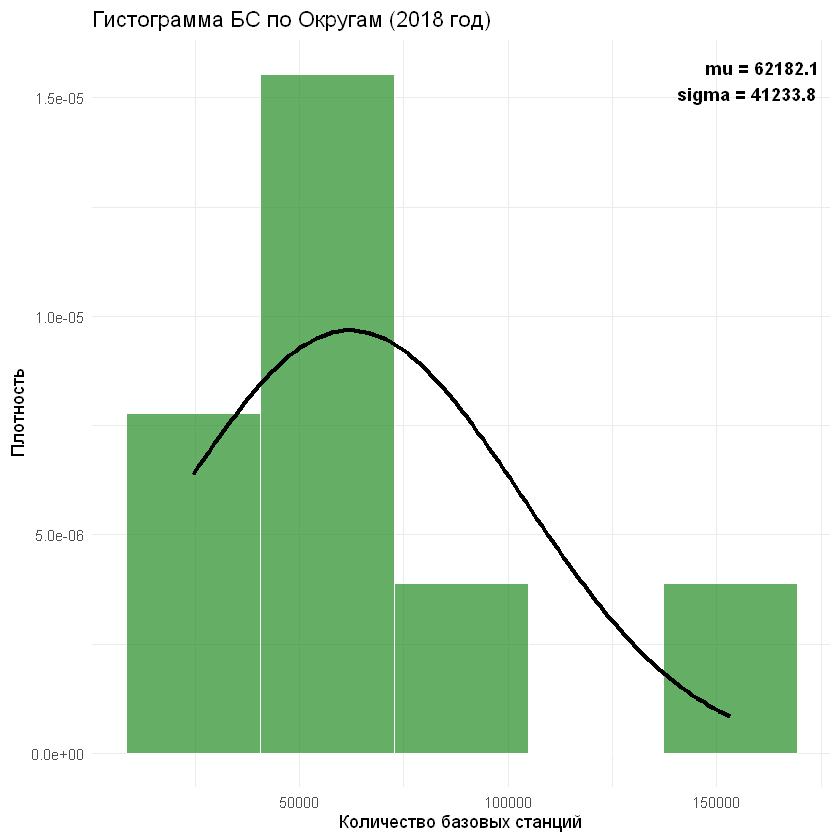

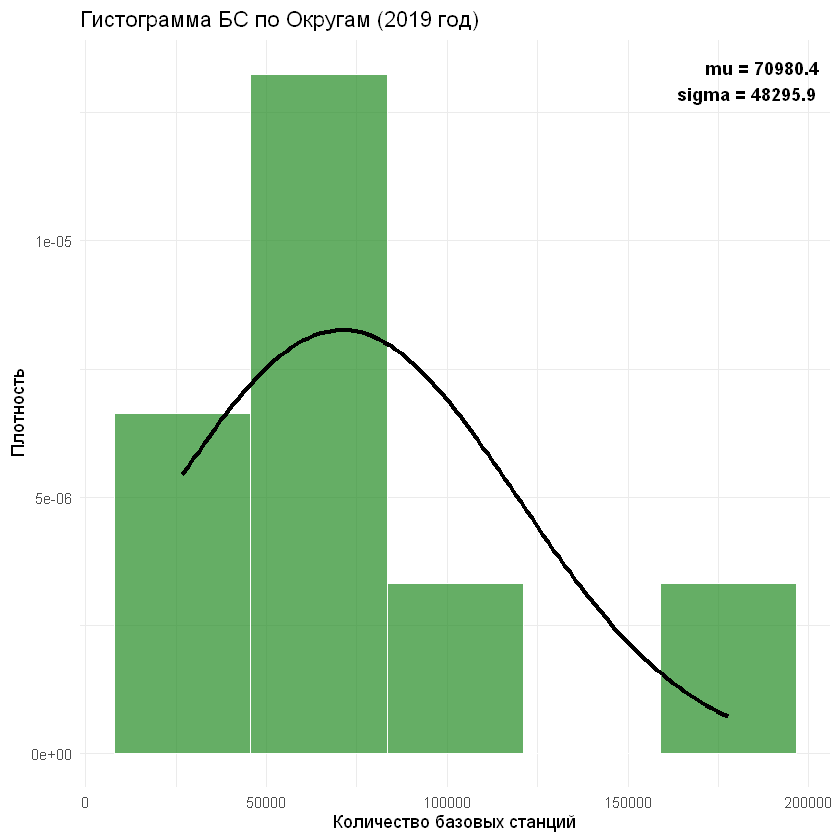

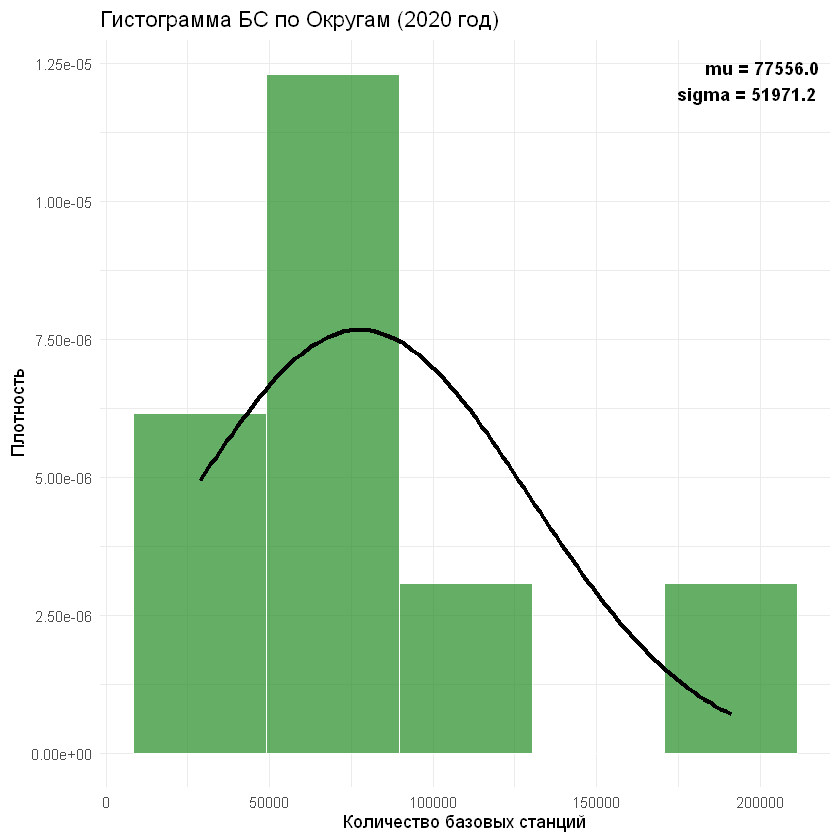

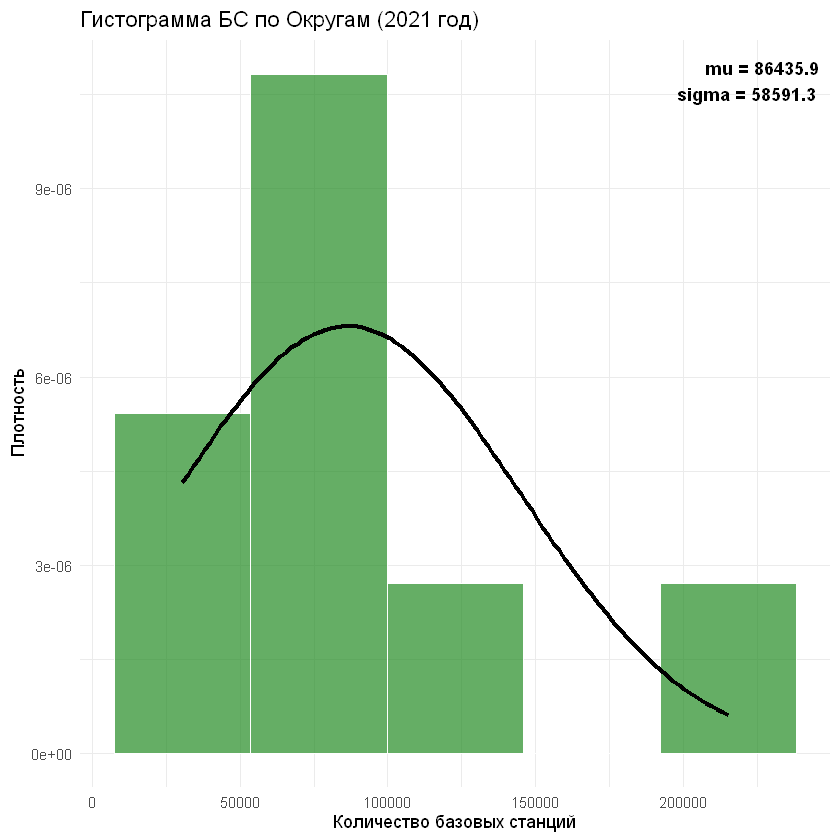

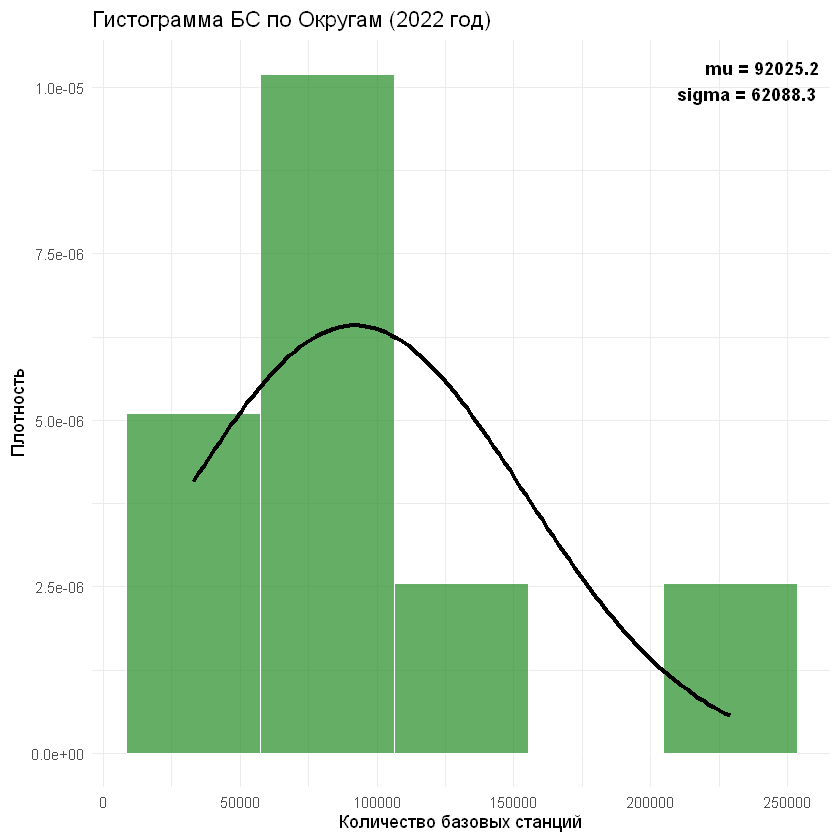

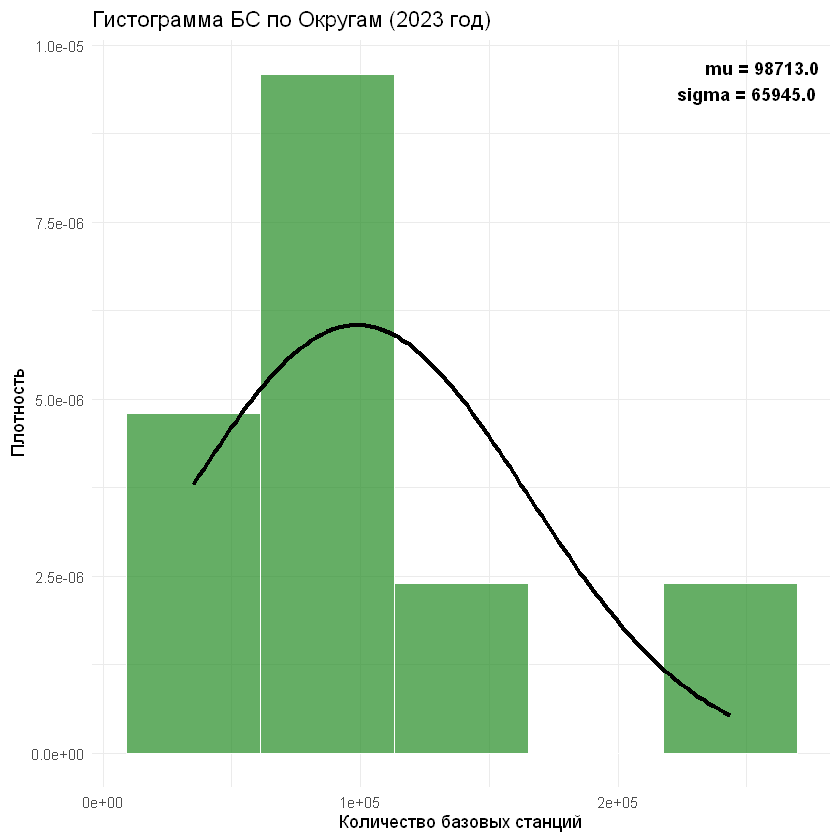

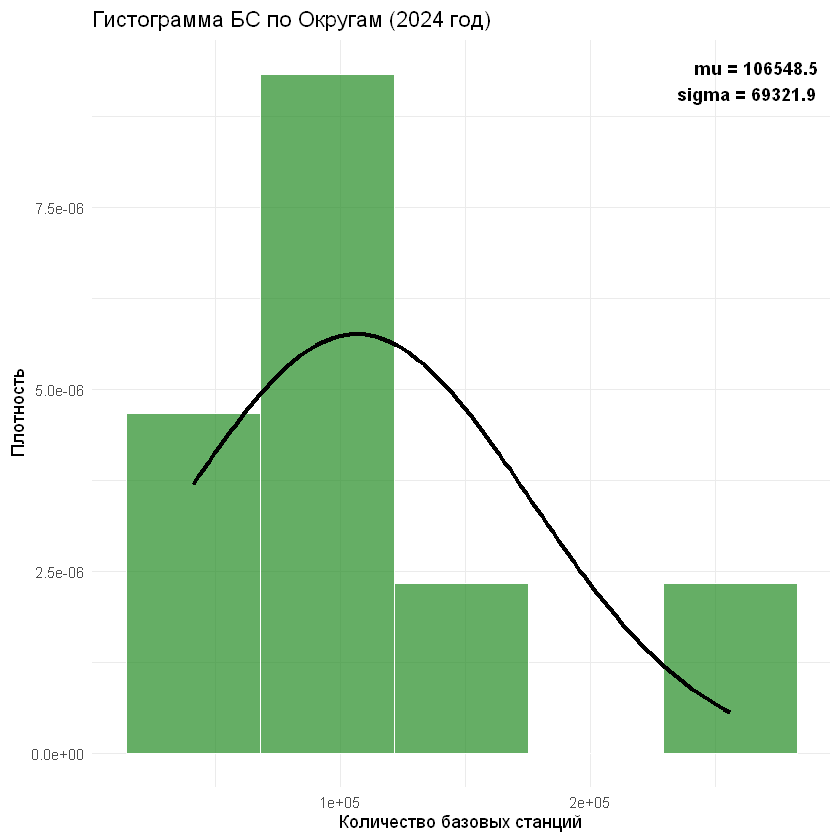

In [12]:
for (year in years) {
  data_year <- districts_df[[year]]
  data_year <- data_year[!is.na(data_year)]
  
  if (length(data_year) > 1) {
    mu <- mean(data_year)
    sigma <- sd(data_year)
    
    p <- ggplot(data.frame(x = data_year), aes(x = x)) +
      geom_histogram(aes(y = after_stat(density)), bins = 5, fill = "forestgreen", color="white", alpha = 0.7) +
      stat_function(fun = dnorm, args = list(mean = mu, sd = sigma), color = "black", linewidth = 1.2) +
      theme_minimal() +
      labs(title = paste("Гистограмма БС по Округам (", year, " год)", sep=""),
           x = "Количество базовых станций", y = "Плотность") + annotate("text", x = Inf, y = Inf, label = sprintf("mu = %.1f\nsigma = %.1f", mu, sigma), 
               hjust = 1.1, vjust = 1.5, fontface="bold")
    print(p)
  }
}

## Пункт 4.3: Гистограммы за все года

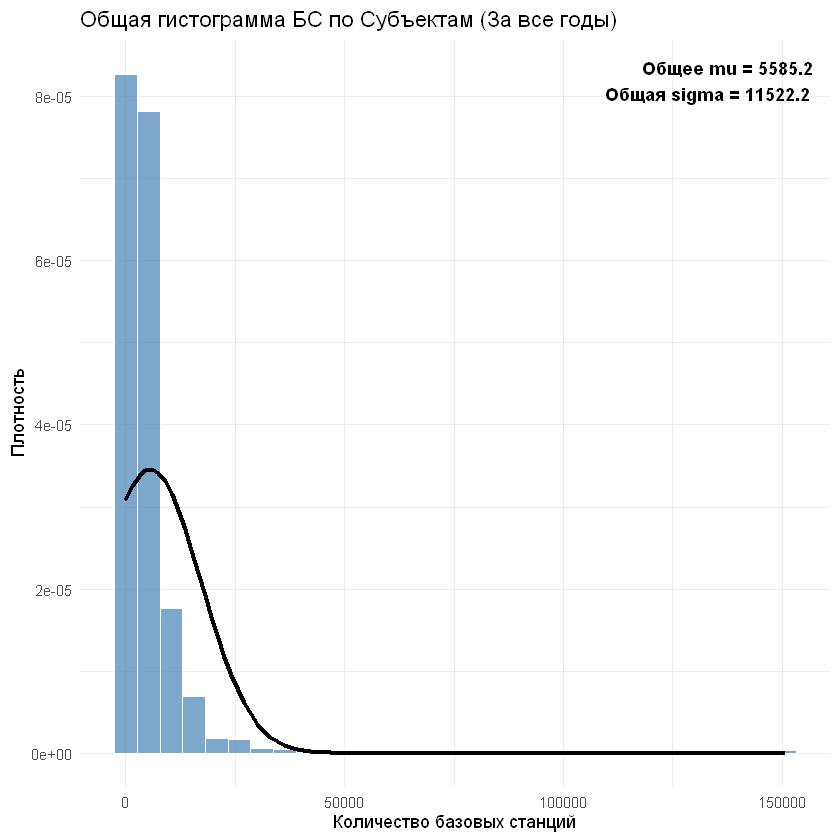

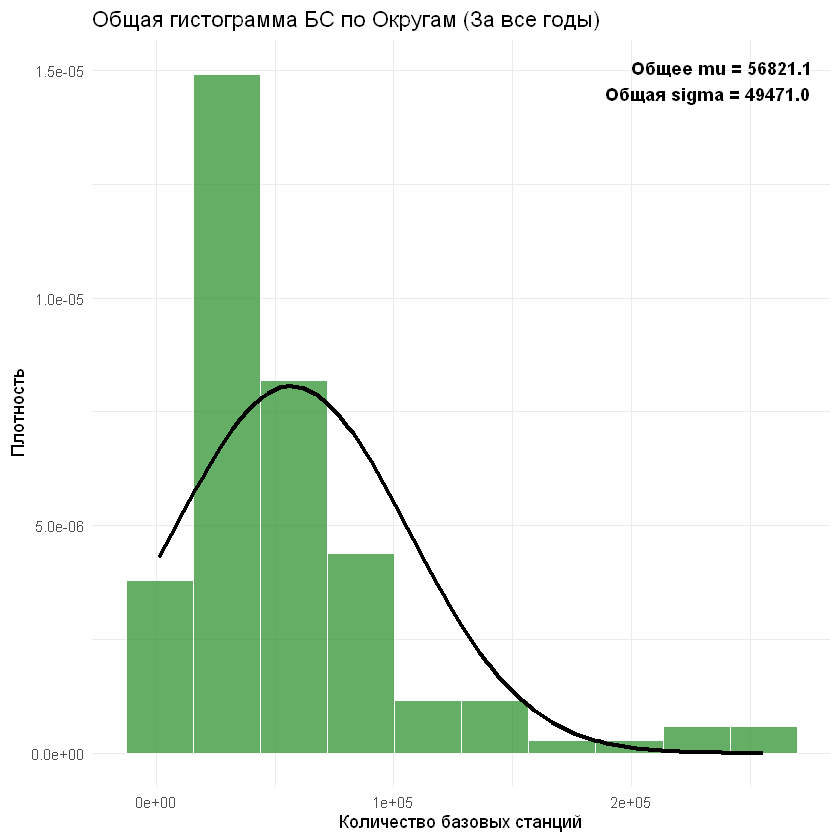

In [20]:

all_data_subj <- unlist(subjects_df[years])
all_data_subj <- all_data_subj[!is.na(all_data_subj)]

mu_all_subj <- mean(all_data_subj)
sigma_all_subj <- sd(all_data_subj)

p_all_subj <- ggplot(data.frame(x = all_data_subj), aes(x = x)) +
  geom_histogram(aes(y = after_stat(density)), bins = 30, fill = "steelblue", color="white", alpha = 0.7) +
  stat_function(fun = dnorm, args = list(mean = mu_all_subj, sd = sigma_all_subj), color = "black", linewidth = 1.2) +
  theme_minimal() +
  labs(title = "Общая гистограмма БС по Субъектам (За все годы)",
       x = "Количество базовых станций", y = "Плотность") +
  annotate("text", x = Inf, y = Inf, label = sprintf("Общее mu = %.1f\nОбщая sigma = %.1f", mu_all_subj, sigma_all_subj), 
           hjust = 1.1, vjust = 1.5, fontface="bold")
print(p_all_subj)

all_data_dist <- unlist(districts_df[years])
all_data_dist <- all_data_dist[!is.na(all_data_dist)]

mu_all_dist <- mean(all_data_dist)
sigma_all_dist <- sd(all_data_dist)

p_all_dist <- ggplot(data.frame(x = all_data_dist), aes(x = x)) +
  geom_histogram(aes(y = after_stat(density)), bins = 10, fill = "forestgreen", color="white", alpha = 0.7) +
  stat_function(fun = dnorm, args = list(mean = mu_all_dist, sd = sigma_all_dist), color = "black", linewidth = 1.2) +
  theme_minimal() +
  labs(title = "Общая гистограмма БС по Округам (За все годы)",
       x = "Количество базовых станций", y = "Плотность") +
  annotate("text", x = Inf, y = Inf, label = sprintf("Общее mu = %.1f\nОбщая sigma = %.1f", mu_all_dist, sigma_all_dist), 
           hjust = 1.1, vjust = 1.5, fontface="bold")
print(p_all_dist)
